# Telco Customer Churn - Exploratory Data Analysis

### The goal of this notebook is to perform Exploratory Data Analysis(EDA) on the cleaned Telco customer churn dataset to understand patterns, relationships and key factors influencing customer churn.

The analysis includes:
  - Understanding the distribution of target variable(Churn)
  - Identifying important numerical and categorical features
  - Exploring relationships between features and churn
  - Extracting meaningful business insights that can help in reducing churn 

In [58]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# Display all columns
pd.set_option('display.max_columns',None)

### 1. Load Dataset

In [60]:
# Load the cleaned dataset for exploratory analysis
# This dataset has already been preprocessed (missing values handled, irrelevant features removed)
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")
df.head(3)

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1


In [61]:
# Get detailed information about the data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Count              7043 non-null   int64  
 1   Country            7043 non-null   object 
 2   State              7043 non-null   object 
 3   City               7043 non-null   object 
 4   Zip Code           7043 non-null   int64  
 5   Lat Long           7043 non-null   object 
 6   Latitude           7043 non-null   float64
 7   Longitude          7043 non-null   float64
 8   Gender             7043 non-null   object 
 9   Senior Citizen     7043 non-null   object 
 10  Partner            7043 non-null   object 
 11  Dependents         7043 non-null   object 
 12  Tenure Months      7043 non-null   int64  
 13  Phone Service      7043 non-null   object 
 14  Multiple Lines     7043 non-null   object 
 15  Internet Service   7043 non-null   object 
 16  Online Security    7043 

### 2. Feature Categorization 

In [62]:
# Identify numerical and categorical features separately
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()

print('Categorical features:', cat_cols)
print('Numerical features:',num_cols)

Categorical features: ['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Numerical features: ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']


### 3. Target Variable Distribution

In [63]:
# Check count of churn vs non-churn customers
df['Churn Value'].value_counts()

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [64]:
# Check proportion
df['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

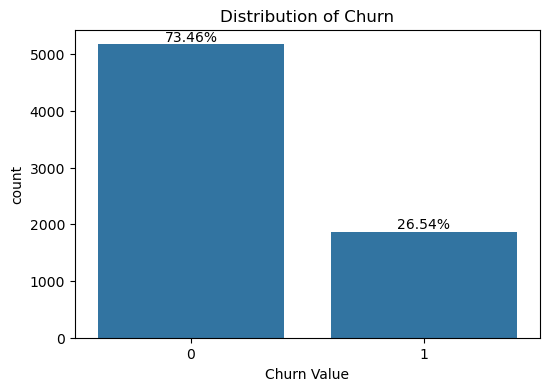

In [65]:
# plot the churn distribution
plt.figure(figsize=(6,4))
plot = sns.countplot(data=df,x='Churn Value')

# Add percentage labels on top of each bar to show proportion of churn vs non-churn 
count = df['Churn Value'].count()
for i in plot.containers:
    plot.bar_label(i, fmt=lambda x: f'{(x/count)*100:0.2f}%')
plt.title('Distribution of Churn')
plt.show()

The churn rate is approximately 26.5% while 73.5% of customers did not churn. This indicates that the dataset is **moderately imbalanced**.

This class imbalance should be considered during model evaluation, as accuracy alone may not be a reliable metric.

### 4. Numerical Feature Analysis

In [66]:
# Remove non-informative or irrelevant numerical features
# 'Count' has no variance, 'Zip Code' is categorical in nature and 
# 'Latitude/Longitude' are not relevant for churn analysis
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value']

#### Add correlation heatmap

The correlation heatmap helps identify relationships between numerical features and detect potential multicollinearity.

In [67]:
corr_matrix = df[num_cols].corr()
corr_matrix

,Tenure Months,Monthly Charges,Total Charges,Churn Value
Tenure Months,1.000000,0.247900,0.826178,-0.352229
Monthly Charges,0.247900,1.000000,0.651174,0.193356
Total Charges,0.826178,0.651174,1.000000,-0.198324
Churn Value,-0.352229,0.193356,-0.198324,1.000000


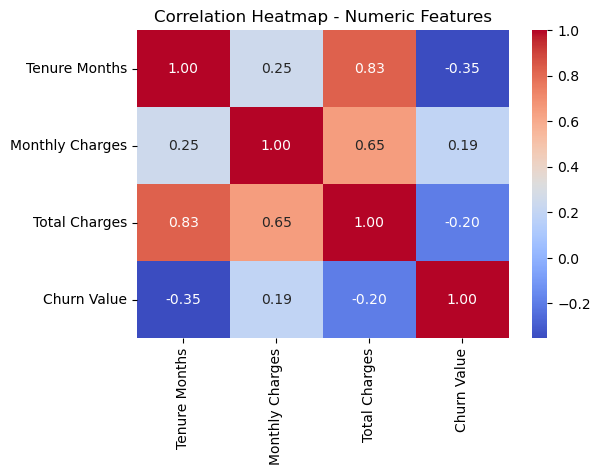

In [68]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features')
plt.show()

 - Among all the numerical features, **Tenure months** shows the strongest negative correlation(-0.35) with churn, indicating customers who stay longer are less likely to churn.
 - Total charges show a strong correlation(0.83) with tenure months, which is expected because total charges accumulate over time as customers stay longer with the service.
 - Monthly charges have a moderate correlation(0.65) with Total charges since total charges = monthly charges x tenure months. However, tenure contributes more strongly to the accumulated total.

### 5. Categorical Feature Analysis

In [69]:
# Exclude high-cardinality and non-relevant features like 'Country','State','City' and 'Lat Long'  
# as they do not provide meaningful insights for churn analysis and may introduce noise
cat_cols = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 
            'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 
            'Payment Method']

#### Feature Importance using Churn Rate Analysis

To identify the most influential categorical features, we compute the churn rate for each category within a feature. Then the **churn spread**(difference between maximum and minimum churn rates) for each feature is calculated. A higher churn spread indicates that the feature has stronger predictive power in distinguishing between churn vs non-churn customers. To ensure realiablity, categories with very low sample counts are excluded. 

In [70]:
feature_importance = []
for col in cat_cols:
    temp_cols = (df.groupby(col)['Churn Value'].agg(['mean','count']).reset_index())

    # Ignore very small categories (optional threshold)
    final_cols = temp_cols[temp_cols['count'] >= 50]

    if len(final_cols) > 1:
        churn_spread = final_cols['mean'].max() - final_cols['mean'].min()
    else:
        churn_spread = 0

    feature_importance.append({
        'Feature' : col,
        'Churn Spread': churn_spread,
        'Min ChurnRate': final_cols['mean'].min() if len(final_cols) > 0 else None,
        'Max ChurnRate': final_cols['mean'].max() if len(final_cols) > 0 else None,
        'Num Categories(>=50 samples)': len(final_cols)
    })

feature_importance_df = pd.DataFrame(feature_importance).sort_values(by='Churn Spread', ascending=False)
feature_importance_df.head()

,Feature,Churn Spread,Min ChurnRate,Max ChurnRate,Num Categories(>=50 samples)
13,Contract,0.398778,0.028319,0.427097,3
6,Internet Service,0.344878,0.074050,0.418928,3
7,Online Security,0.343617,0.074050,0.417667,3
10,Tech Support,0.342305,0.074050,0.416355,3
8,Online Backup,0.325238,0.074050,0.399288,3


In [71]:
feature_importance_df.tail(3)

,Feature,Churn Spread,Min ChurnRate,Max ChurnRate,Num Categories(>=50 samples)
5,Multiple Lines,0.036832,0.249267,0.286099,3
4,Phone Service,0.017830,0.249267,0.267096,2
0,Gender,0.007605,0.261603,0.269209,2


#### Visualization of Feature Importance

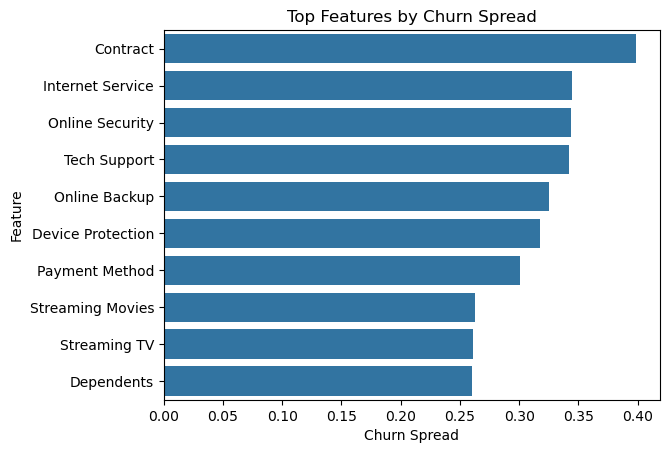

In [72]:
sns.barplot(data=feature_importance_df.head(10), x='Churn Spread', y='Feature')
plt.title('Top Features by Churn Spread')
plt.show()

- **Contract** is the most influential feature, with the highest churn spread(~40) indicating customers under each contract type churn differently.
- Features like **Internet Service, Online Security, Tech Support** also show strong influence, showing service quality and add-ons impact customer retention.
- Features like **Multiple Lines, Phone Service, Gender** have very low churn spread indicating they have minimal impact on churn prediction. 

### 6. Focused EDA on Top Features

#### 6.1. Compare tenure distribution between churned and retained customers

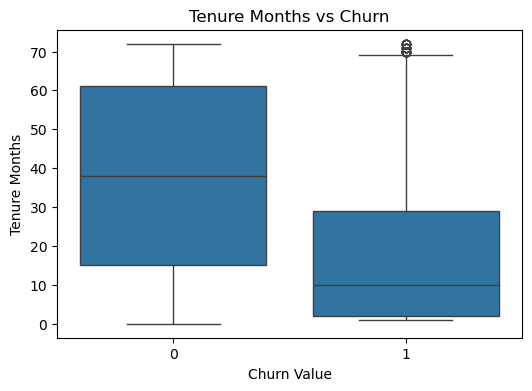

In [73]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)
plt.title('Tenure Months vs Churn')
plt.show()

 - Customers who churn generally have much lower tenure than those who stay. This suggests that customers are more likely to leave during the early stages of their relationship with the company.
 - A few tenure customers still churn, indicating that longer tenure reduces risk but does not eliminate it.

#### 6.2. Compare monthly charges between churned and retained customers

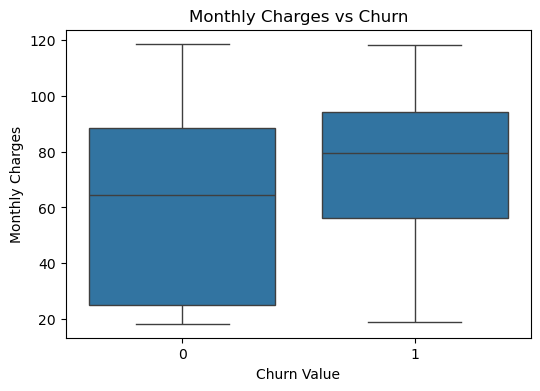

In [74]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Churn Value', y='Monthly Charges')
plt.title('Monthly Charges vs Churn')
plt.show()

 - Customers who churn tend to have higher monthly charges compared to customers who stay. This suggests pricing may contribute to churn behavior.

#### 6.3. Visualize churn rate across contract types

In [75]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

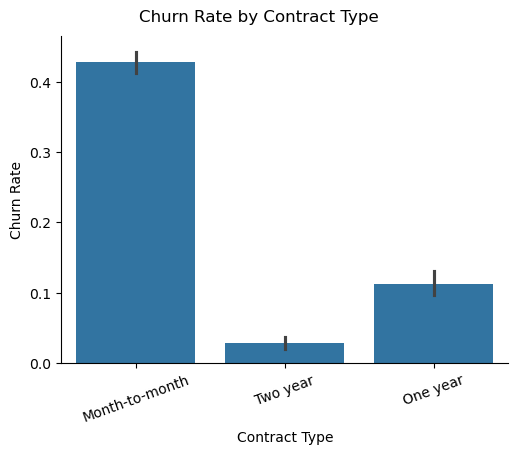

In [76]:
g = sns.catplot(data=df, x='Contract',y='Churn Value', kind='bar', height=4, aspect=1.3)
g.set_axis_labels('Contract Type', 'Churn Rate')
g.fig.suptitle('Churn Rate by Contract Type', y=1.03)
plt.xticks(rotation=20)
plt.show()

 - Customers on month-to-month contracts show the highest churn rate by a large margin.
 - Customers on one-year and especially two-year contracts are much less likely to churn.
 - This indicates that contract length is one of the strongest factors associated with customer retention.

#### 6.4. Visualize churn rate across internet service categories

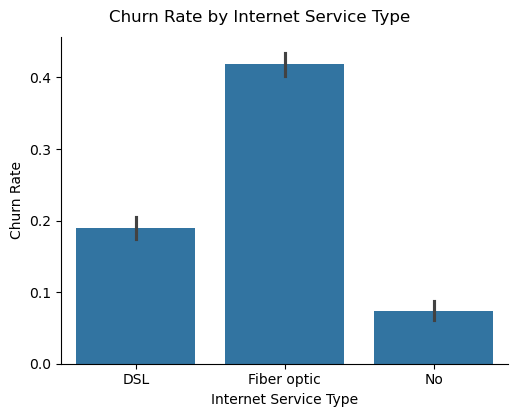

In [77]:
g = sns.catplot(data=df, x='Internet Service',y='Churn Value', kind='bar', height=4, aspect=1.3)
g.set_axis_labels('Internet Service Type', 'Churn Rate')
g.fig.suptitle('Churn Rate by Internet Service Type', y=1.03)
plt.show()

- Customers using fiber optic internet service show the highest churn rate among the three categories. This suggests that internet service type is strongly associated with churn behavior.
- The higher churn among fiber optic users may reflect differences in pricing, expectations or service experience and would require further business investigation.

### Final insights

The focused EDA highlights the following important patterns related to customer churn:
 - Customers with lower tenure are much more likely to churn, indicating that churn risk is highest in the early stage of customer lifecycle.
 - Higher monthly charges may increase perceived cost burden, leading to higher churn especially among short-tenure customers.
 - Contract type is one of the strongest drivers of churn, with month-to-month customers showing substantially higher churn rates than customers on longer-term contracts.
 - Internet service type is also strongly associated with churn, with fiber optic customers showing the highest churn rate among service categories.

Overall tenure, contract type, monthly charges and internet service emerge as key features for churn prediction and should be retained for downstream modeling.

### Next Steps for Modeling

 - Perform feature engineering and feature encoding (one-hot/ label encoding)
 - Handle class-imbalance 
 - Train baseline models (Logistic Regression)
 - Evaluate using ROC-AUC, Precision-Recall
 - Tune threshold based on business needs